# World Cup 2026 knockout Monte Carlo simulation

This executable report builds chronological Elo ratings from historical international results, continues those ratings through the 2026 group stage, combines Elo with short-term group form, and simulates the supplied knockout bracket. All inputs are local CSV files: this notebook performs no internet access.

## Setup and configuration

The seed makes repeated runs reproducible. Increase `N_SIMULATIONS` after a quick end-to-end check; 100,000 simulations produce more stable tail probabilities but take longer.

In [28]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analysis import (
    run_weight_sensitivity,
    save_match_probability_tables,
    save_probability_tables,
    save_standard_plots,
)
from src.data_loading import (
    load_bracket,
    load_group_stage,
    load_historical_results,
)
from src.match_model import PoissonMatchModel
from src.ratings import (
    EloConfig,
    combine_strengths,
    compute_group_form,
    update_elo_ratings,
    update_elo_with_warmup,
)
from src.tournament import TournamentSimulator

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"

SEED = 2026
N_SIMULATIONS = 1_000_000
SENSITIVITY_SIMULATIONS = 5_000
HISTORICAL_START_DATE = "1990-01-01"
FULL_WEIGHT_START_DATE = "2018-01-01"
HISTORICAL_END_DATE = "2026-06-10"
WARMUP_K_SCALE = 0.20
HISTORICAL_WEIGHT = 0.70
GROUP_WEIGHT = 0.30
STATIC_ELO = True  # freeze post-group Elo during knockout simulations
FIFA_WC2026_K_FACTOR = 60.0

K_FACTORS = {
    "Friendly": 10,
    "UEFA Nations League": 20,
    "FIFA World Cup qualification": 25,
    "UEFA Euro qualification": 25,
    "Copa América": 35,
    "UEFA Euro": 35,
    "FIFA World Cup": 50,
}

ELO_CONFIG = EloConfig(
    initial_elo=1500.0,
    k_factor=20.0,  # fallback for tournaments not listed above
    home_advantage=100.0,
    rating_scale=400.0,
    sort_by_date=True,
    tournament_k_factors=K_FACTORS,
)
GROUP_STAGE_ELO_CONFIG = replace(
    ELO_CONFIG,
    tournament_k_factors={
        **K_FACTORS,
        "FIFA World Cup": FIFA_WC2026_K_FACTOR,
    },
)
MATCH_MODEL = PoissonMatchModel(base_goals=1.35, strength_exponent=1.0)


## Load and validate historical data

Historical rows without a completed score are removed and only the seven Elo fields are retained. Matches from 1990 through 2017 provide a low-weight calibration period; updates from 2018 onward receive their full configured weight.

In [29]:
historical = load_historical_results(
    DATA_DIR / "historical_results.csv",
    start_date=HISTORICAL_START_DATE,
    end_date=HISTORICAL_END_DATE,
)

print(f"Historical matches: {len(historical):,}")
print(f"Historical window: {historical['date'].min().date()} to {historical['date'].max().date()}")
print(f"Teams observed: {len(set(historical['home_team']) | set(historical['away_team'])):,}")
display(historical.head())


Historical matches: 32,287
Historical window: 1990-01-12 to 2026-06-10
Teams observed: 326


,date,home_team,away_team,home_score,away_score,tournament,neutral
0,1990-01-12,Algeria,Mali,5,0,Friendly,True
1,1990-01-14,Algeria,Cameroon,3,1,Friendly,True
2,1990-01-17,Greece,Belgium,2,0,Friendly,False
3,1990-01-17,Mexico,Argentina,2,0,Friendly,True
4,1990-01-20,Malawi,Tanzania,2,2,Friendly,True


## Chronological Elo ratings

The historical frame is stably sorted by date and each result updates both teams immediately before the next match is processed. From 1990 through 2017, all K-factors are multiplied by `WARMUP_K_SCALE=0.20`; from 2018 onward, normal competition-specific K-factors apply. Historical matches use the `neutral` flag to control home advantage, and unlisted competitions use the configured fallback K. The audit table records the phase, applied K, and ratings before and after every update.

In [30]:
historical_elo, historical_elo_history = update_elo_with_warmup(
    historical,
    full_weight_start_date=FULL_WEIGHT_START_DATE,
    warmup_k_scale=WARMUP_K_SCALE,
    config=ELO_CONFIG,
)

elo_table = (
    pd.Series(historical_elo, name="historical_elo")
    .sort_values(ascending=False)
    .to_frame()
)
phase_counts = historical_elo_history['phase'].value_counts()
print(f"Warm-up Elo updates: {phase_counts.get('warmup', 0):,}")
print(f"Full-weight Elo updates: {phase_counts.get('full_weight', 0):,}")
display(elo_table.head(32).style.format("{:.1f}"))
display(historical_elo_history.tail())


Warm-up Elo updates: 24,179
Full-weight Elo updates: 8,108


,historical_elo
Spain,1889.7
Argentina,1856.3
France,1838.8
England,1797.2
Morocco,1785.4
Portugal,1775.1
Japan,1772.5
Netherlands,1761.7
Brazil,1759.5
Senegal,1751.5


,source_index,date,home_team,away_team,tournament,k_factor,home_elo_before,away_elo_before,expected_home,actual_home,elo_change,home_elo_after,away_elo_after,phase
32282,32282,2026-06-09,Iraq,Venezuela,Friendly,10.0,1668.880288,1560.064694,0.651671,0.0,-6.516711,1662.363577,1566.581405,full_weight
32283,32283,2026-06-10,Bolivia,Algeria,Friendly,10.0,1466.832445,1734.418220,0.176485,0.0,-1.764848,1465.067598,1736.183068,full_weight
32284,32284,2026-06-10,England,Costa Rica,Friendly,10.0,1794.448877,1626.781651,0.724156,1.0,2.758442,1797.207319,1624.023208,full_weight
32285,32285,2026-06-10,Portugal,Nigeria,Friendly,10.0,1772.388722,1700.675062,0.728784,1.0,2.712157,1775.100879,1697.962905,full_weight
32286,32286,2026-06-10,Afghanistan,Pakistan,Diamond Jubilee International Football Tournament,20.0,1421.940593,1331.079764,0.627858,0.0,-12.557153,1409.383440,1343.636917,full_weight


## Continue Elo through the 2026 group stage

Once the remaining two CSV files are present, load and validate them here. Group-stage Elo starts from the final historical ratings, uses the `neutral` flag supplied by the CSV, and applies the dedicated 2026 group-stage K-factor.

In [31]:
group_stage = load_group_stage(DATA_DIR / "group_stage_2026.csv")
bracket = load_bracket(DATA_DIR / "bracket_2026.csv")
final_elo, group_elo_history = update_elo_ratings(
    group_stage,
    initial_ratings=historical_elo,
    config=GROUP_STAGE_ELO_CONFIG,
)

print(f"Group-stage matches: {len(group_stage):,}")
print(f"Bracket matches: {len(bracket):,}")
post_group_elo_table = pd.Series(final_elo, name="post_group_elo").sort_values(ascending=False).to_frame()
display(post_group_elo_table.head(20).style.format("{:.1f}"))


Group-stage matches: 72
Bracket matches: 31


,post_group_elo
Argentina,1900.5
Spain,1894.5
France,1893.0
England,1820.1
Morocco,1814.5
Netherlands,1797.3
Brazil,1795.6
Portugal,1783.5
Colombia,1777.4
Japan,1774.9


## Group-stage form

Form combines points per game, goal difference per game, and goals scored per game. If both xG columns are present, xG difference per game is included automatically.

In [32]:
group_form = compute_group_form(group_stage)
display(group_form.style.format(precision=3))


,played,points,goals_for,goals_against,goal_difference,points_per_game,goals_for_per_game,goal_difference_per_game,form_score
team,,,,,,,,,
France,3,9.000,10.000,2.000,8.000,3.000,3.333,2.667,3.867
Argentina,3,9.000,8.000,1.000,7.000,3.000,2.667,2.333,3.733
Mexico,3,9.000,6.000,0.000,6.000,3.000,2.000,2.000,3.600
Netherlands,3,7.000,10.000,4.000,6.000,2.333,3.333,2.000,3.067
Brazil,3,7.000,7.000,1.000,6.000,2.333,2.333,2.000,2.967
Spain,3,7.000,5.000,0.000,5.000,2.333,1.667,1.667,2.833
Switzerland,3,7.000,7.000,3.000,4.000,2.333,2.333,1.333,2.833
England,3,7.000,6.000,2.000,4.000,2.333,2.000,1.333,2.800
Morocco,3,7.000,6.000,3.000,3.000,2.333,2.000,1.000,2.733


## Combine long-term rating and tournament form

Both inputs are min-max normalized before applying the configurable 70/30 rule:

$$\text{final strength}=0.7\,\text{normalized Elo}+0.3\,\text{normalized group form}$$

A small positive floor keeps all goal-rate and penalty calculations well-defined.

In [33]:
bracket_teams = sorted(
    set(bracket.loc[bracket["round"] == "R32", "team_a"])
    | set(bracket.loc[bracket["round"] == "R32", "team_b"])
)
strength_table = combine_strengths(
    final_elo,
    group_form,
    teams=bracket_teams,
    historical_weight=HISTORICAL_WEIGHT,
    group_weight=GROUP_WEIGHT,
    missing_elo=ELO_CONFIG.initial_elo,
)
display(strength_table.loc[bracket_teams].sort_values("final_strength", ascending=False).style.format(precision=3))


,elo,normalized_elo,form_score,normalized_group_form,final_strength
team,,,,,
Argentina,1900.544,1.000,3.733,0.971,0.991
France,1893.016,0.980,3.867,1.000,0.986
Spain,1894.540,0.984,2.833,0.774,0.921
England,1820.072,0.783,2.800,0.766,0.778
Morocco,1814.457,0.767,2.733,0.752,0.763
Netherlands,1797.252,0.721,3.067,0.825,0.752
Mexico,1774.005,0.658,3.600,0.942,0.743
Brazil,1795.622,0.717,2.967,0.803,0.742
Colombia,1777.408,0.667,2.667,0.737,0.688


## Poisson match model and Monte Carlo tournament

For equal teams, each side scores `base_goals` on average. Relative strength scales the two Poisson rates in opposite directions. Every knockout match is simulated on neutral ground, with no home advantage for either bracket slot. Tied knockout games use one-third-rate extra time and then a strength-weighted penalty shootout. The simulator follows only the feeder links in `bracket_2026.csv`; it never creates random pairings.

In [34]:
simulator = TournamentSimulator(
    bracket,
    strength_table["final_strength"],
    match_model=MATCH_MODEL,
    static_elo=STATIC_ELO,
)
simulation_report = simulator.simulate_many_detailed(
    n_simulations=N_SIMULATIONS,
    seed=SEED,
    show_progress=True,
)
stage_probabilities = simulation_report.stage_probabilities
display(stage_probabilities.style.format("{:.2%}"))


Simulating tournaments:   0%|          | 0/1000000 [00:00<?, ?sim/s]

,Round of 16,Quarterfinal,Semifinal,Final,Champion
team,,,,,
Argentina,99.39%,89.13%,69.72%,50.04%,29.58%
France,98.32%,80.88%,57.11%,37.80%,23.00%
Spain,93.01%,69.38%,59.61%,32.35%,18.21%
England,91.43%,53.87%,33.60%,14.20%,6.00%
Morocco,51.08%,47.68%,18.22%,9.01%,3.89%
Mexico,81.62%,41.15%,24.44%,9.62%,3.76%
Netherlands,48.92%,45.45%,16.96%,8.23%,3.46%
Brazil,59.63%,42.52%,21.22%,8.33%,3.24%
Colombia,95.88%,59.63%,17.99%,8.39%,2.85%


## Probabilities for every bracket match

`matchup_probability` is the chance that the named pairing actually occurs in that bracket slot. The win probabilities are conditional on that pairing occurring. The compact table below keeps the most likely pairing for every match; the complete output is saved later.

In [ ]:
match_columns = [
    "match_id",
    "round",
    "team_a",
    "team_b",
    "matchup_probability",
    "favorite",
    "favorite_win_probability",
]
display(
    simulation_report.most_likely_matchups[match_columns].style.format(
        {
            "matchup_probability": "{:.2%}",
            "favorite_win_probability": "{:.2%}",
        }
    )
)


## Save tables and plots

Saved tables:
 - outputs/stage_probabilities.csv
 - outputs/winner_probabilities.csv
Saved plots:
 - outputs/plots/winner_probabilities.png
 - outputs/plots/final_probabilities.png
 - outputs/plots/stage_probability_heatmap.png


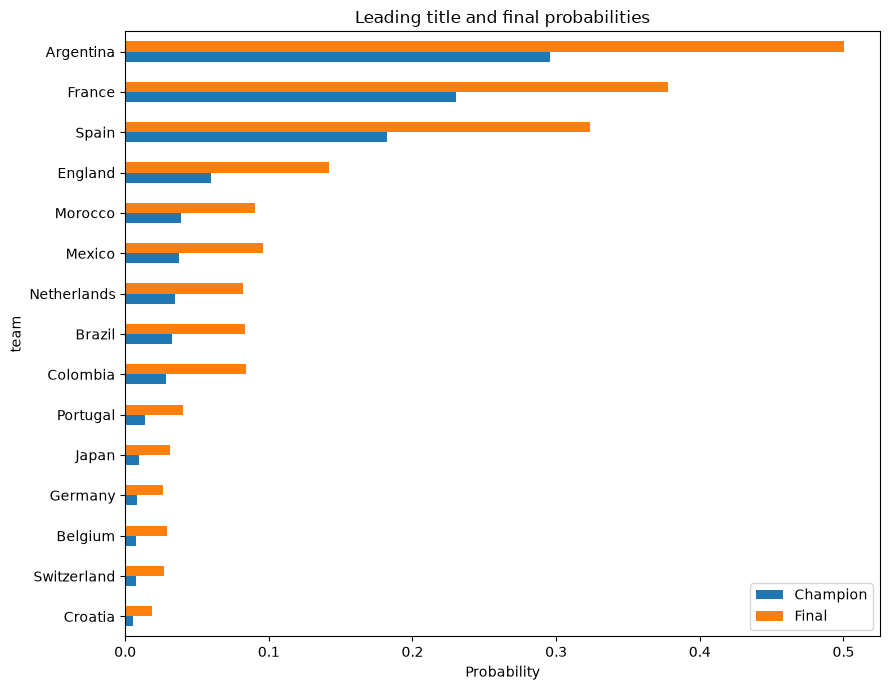

In [35]:
table_paths = save_probability_tables(stage_probabilities, OUTPUT_DIR)
table_paths.update(
    save_match_probability_tables(
        simulation_report.matchup_probabilities,
        simulation_report.most_likely_matchups,
        simulation_report.team_match_probabilities,
        OUTPUT_DIR,
    )
)
plot_paths = save_standard_plots(stage_probabilities, OUTPUT_DIR / "plots")

print("Saved tables:")
for path in table_paths.values():
    print(" -", path.relative_to(ROOT))
print("Saved plots:")
for path in plot_paths.values():
    print(" -", path.relative_to(ROOT))

stage_probabilities[["Champion", "Final"]].head(15).sort_values("Champion").plot.barh(
    figsize=(9, 7),
    title="Leading title and final probabilities",
)
plt.xlabel("Probability")
plt.tight_layout()
plt.show()


## Sensitivity to the group-stage weight

The scenarios below use group-form weights 0.0, 0.1, 0.3, and 0.5. The complementary weight is assigned to Elo. Reusing the seed reduces irrelevant Monte Carlo variation between scenarios.

,group_weight_0.0,group_weight_0.1,group_weight_0.3,group_weight_0.5
team,,,,
Argentina,31.28%,30.02%,29.74%,28.88%
France,20.86%,22.76%,23.62%,24.38%
Spain,22.88%,21.46%,17.96%,13.48%
England,7.30%,7.06%,5.52%,4.76%
Morocco,4.62%,3.72%,4.14%,3.58%
Mexico,1.40%,2.06%,3.68%,6.00%
Netherlands,2.14%,2.60%,3.62%,4.46%
Brazil,2.76%,2.94%,3.10%,3.58%
Colombia,2.20%,2.26%,2.48%,2.96%


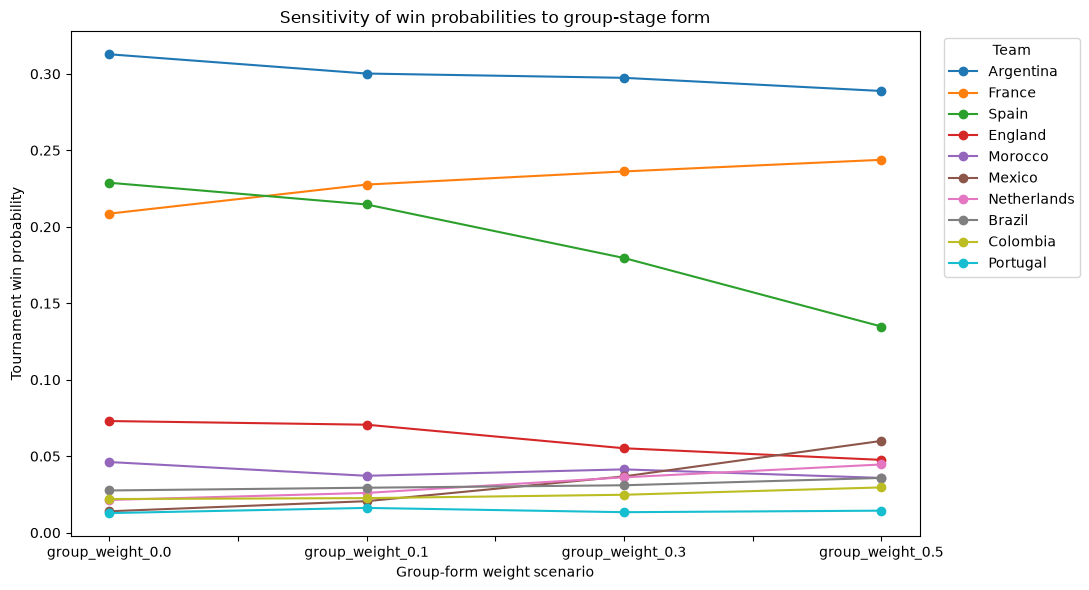

In [36]:
def simulator_for_group_weight(group_weight: float) -> TournamentSimulator:
    scenario_strengths = combine_strengths(
        final_elo,
        group_form,
        teams=bracket_teams,
        historical_weight=1.0 - group_weight,
        group_weight=group_weight,
        missing_elo=ELO_CONFIG.initial_elo,
    )
    return TournamentSimulator(
        bracket,
        scenario_strengths["final_strength"],
        match_model=MATCH_MODEL,
        static_elo=STATIC_ELO,
    )

sensitivity = run_weight_sensitivity(
    group_weights=[0.0, 0.1, 0.3, 0.5],
    simulation_factory=simulator_for_group_weight,
    n_simulations=SENSITIVITY_SIMULATIONS,
    seed=SEED,
)
leading_teams = stage_probabilities.head(10).index
display(sensitivity.loc[leading_teams].style.format("{:.2%}"))

ax = sensitivity.loc[leading_teams].T.plot(figsize=(11, 6), marker="o")
ax.set_xlabel("Group-form weight scenario")
ax.set_ylabel("Tournament win probability")
ax.set_title("Sensitivity of win probabilities to group-stage form")
ax.legend(title="Team", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Interpretation cautions

These are model probabilities, not certainties. Results depend on Elo settings, the form formula, the strength-to-goals mapping, and the supplied bracket. The independent Poisson model omits injuries, lineups, tactical effects, correlated scores, and team-specific penalty skill. Use the sensitivity table as a reminder that small modeling choices can move the estimates.